# Install DARTS

### 📈 **Darts: A Modern Time Series Forecasting Library**

Darts is a Python library designed to make time series forecasting and anomaly detection intuitive and powerful. It supports a wide range of models—from classical statistical approaches like ARIMA to cutting-edge deep learning architectures.

🔧 Key Features
- Unified API: All models use fit() and predict() methods, similar to scikit-learn.
- Model Variety: Includes ARIMA, Prophet, RNNs, Transformers, and more.
- Multivariate Support: Handles both univariate and multivariate time series.
- Probabilistic Forecasting: Offers uncertainty estimates for predictions.
- Backtesting & Ensembling: Easily evaluate and combine models.
- External Data Integration: Incorporate covariates and exogenous variables.

🧠 Use Cases
- Demand forecasting
- Predictive maintenance
- Financial time series analysis
- Energy consumption modeling

In [ ]:
! pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88

# Import Other Packages and Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /LSTM/nyc_data.csv',
                 index_col='Date',
                 parse_dates=True)
df.head()

,Demand,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2015-01-01,720.000885,0,0,0,3.68,41.305
2015-01-02,581.276773,0,0,0,4.73,131.574
2015-01-03,754.117039,0,0,0,7.23,162.700
2015-01-04,622.252774,0,0,0,10.96,160.281
2015-01-05,785.373319,0,0,0,6.92,51.077


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2192 entries, 2015-01-01 to 2020-12-31
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Demand        2192 non-null   float64
 1   Easter        2192 non-null   int64  
 2   Thanksgiving  2192 non-null   int64  
 3   Christmas     2192 non-null   int64  
 4   Temperature   2192 non-null   float64
 5   Marketing     2192 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 119.9 KB


In [ ]:
df = df.asfreq('D')
df.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', name='Date', length=2192, freq='D')

In [ ]:
# Change the target variable column name 'Demand' to 'y'

df = df.rename(columns={'Demand': 'y'})
df.head()

,y,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2015-01-01,720.000885,0,0,0,3.68,41.305
2015-01-02,581.276773,0,0,0,4.73,131.574
2015-01-03,754.117039,0,0,0,7.23,162.700
2015-01-04,622.252774,0,0,0,10.96,160.281
2015-01-05,785.373319,0,0,0,6.92,51.077


# EDA

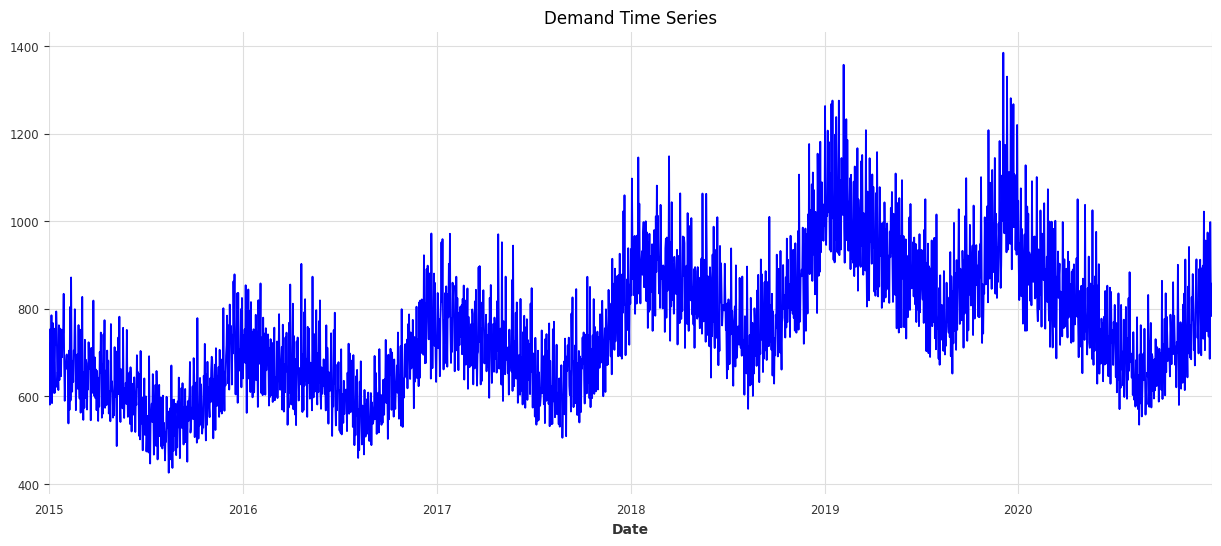

In [ ]:
plt.figure(figsize=(15, 6))
df['y'].plot(title = 'Demand Time Series', color='blue')
plt.show()

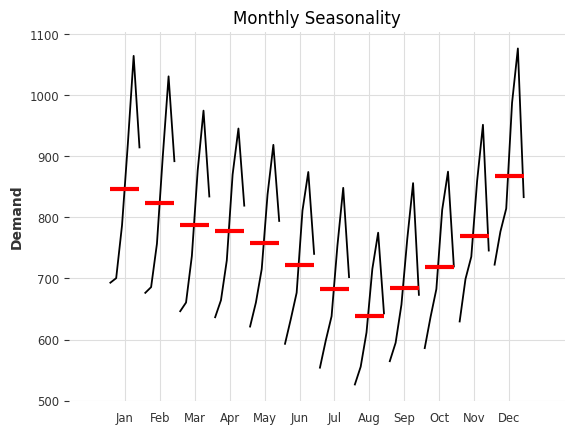

In [ ]:
# Monthly Seasonality
month_plot(df['y'].resample('M').mean())
plt.title('Monthly Seasonality')
plt.ylabel('Demand')
plt.show()

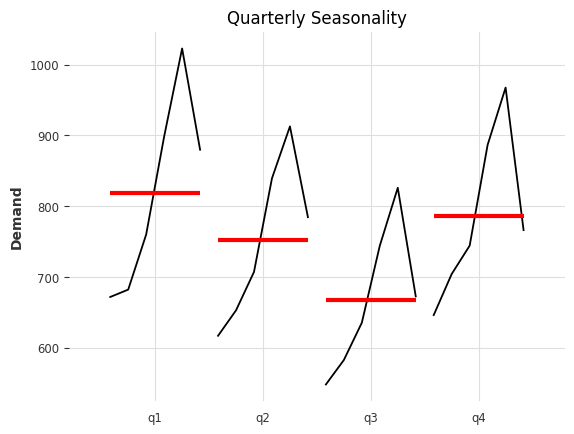

In [ ]:
# Quarterly Seasonality

quarter_plot(df['y'].resample('Q').mean())
plt.title('Quarterly Seasonality')
plt.ylabel('Demand')
plt.show()

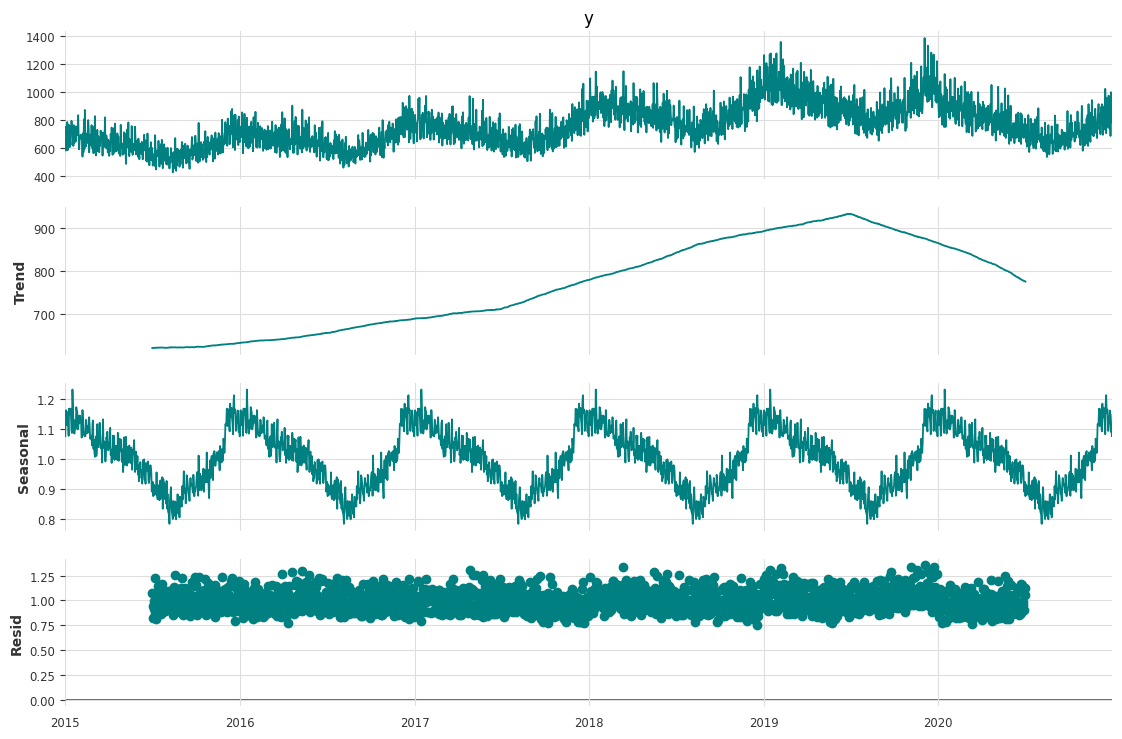

In [ ]:
# Seasonal decomposition of 'Demand'  (12 month period, model='additive')

result = seasonal_decompose(df['y'], model='multiplicative', period=365)
fig = result.plot()

# Change line color to blue for all axes
for ax in fig.axes:
    for line in ax.get_lines():
        line.set_color('teal')

# Adjust figure size (if needed)
fig.set_size_inches(12, 8)
plt.show()


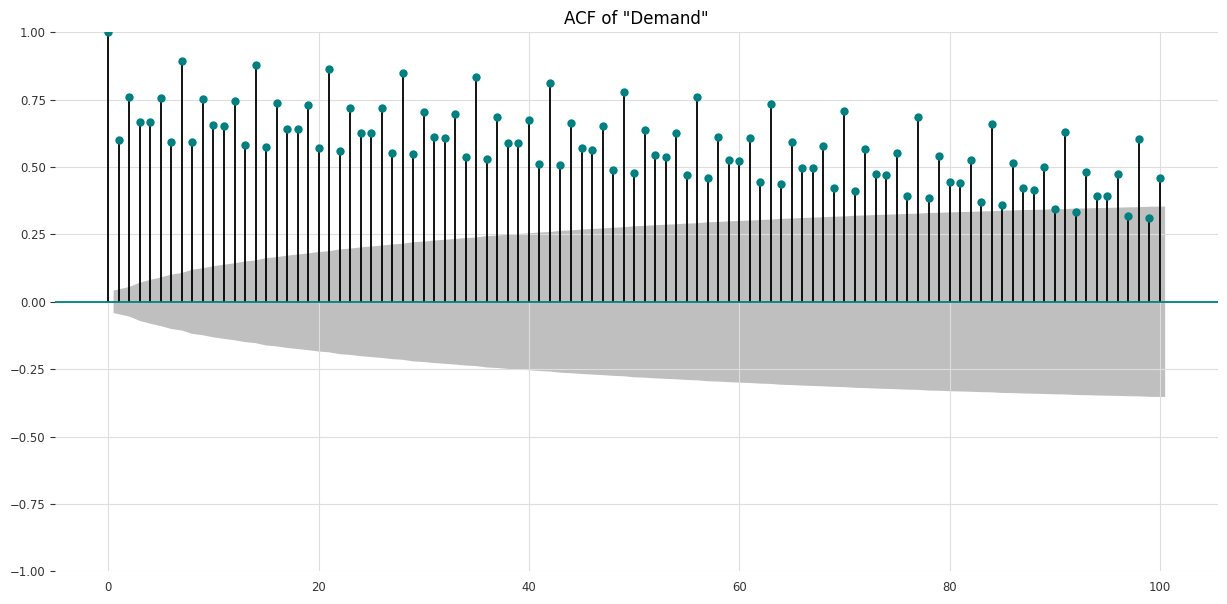

In [ ]:
# Plot the ACF for the 'Demand' data
fig, ax = plt.subplots(figsize=(15,7))
plot_acf(df['y'], lags=100, ax=ax, color='teal')
plt.title('ACF of "Demand"')
plt.show()

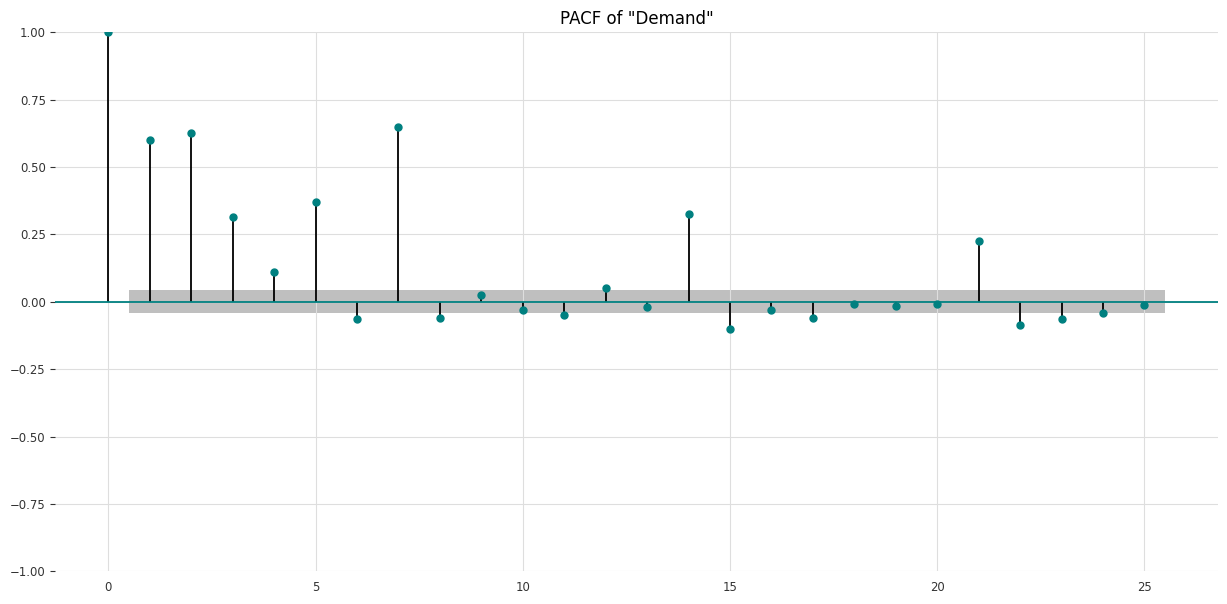

In [ ]:
# PACF of 'Demand'
fig, ax = plt.subplots(figsize=(15,7))
plot_pacf(df['y'], lags=25, ax=ax, color='teal')
plt.title('PACF of "Demand"')
plt.show()

# Prepare for LSTM

In [ ]:
# Prepare the time-series object

series = TimeSeries.from_series(df.y)
covariates = TimeSeries.from_dataframe(df.iloc[:,1:])
series

<TimeSeries (Date: 2192, component: 1, sample: 1)> Size: 18kB
array([[[720.0008852]],

       [[581.2767734]],

       [[754.117039 ]],

       ...,

       [[847.1233994]],

       [[857.5210429]],

       [[783.8914943]]])
Coordinates:
  * Date       (Date) datetime64[ns] 18kB 2015-01-01 2015-01-02 ... 2020-12-31
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
covariates

<TimeSeries (Date: 2192, component: 5, sample: 1)> Size: 88kB
array([[[  0.   ],
        [  0.   ],
        [  0.   ],
        [  3.68 ],
        [ 41.305]],

       [[  0.   ],
        [  0.   ],
        [  0.   ],
        [  4.73 ],
        [131.574]],

       [[  0.   ],
        [  0.   ],
        [  0.   ],
        [  7.23 ],
        [162.7  ]],

       ...,

       [[  0.   ],
        [  0.   ],
        [  0.   ],
        [  3.48 ],
        [161.865]],

       [[  0.   ],
        [  0.   ],
        [  0.   ],
        [  5.97 ],
        [179.634]],

       [[  0.   ],
        [  0.   ],
        [  0.   ],
        [  8.22 ],
        [149.221]]])
Coordinates:
  * Date       (Date) datetime64[ns] 18kB 2015-01-01 2015-01-02 ... 2020-12-31
  * component  (component) object 40B 'Easter' 'Thanksgiving' ... 'Marketing'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
# Year

year_series = datetime_attribute_timeseries(
                  pd.date_range(start = series.start_time(),
                  freq = series.freq_str,
                  periods = df.shape[0]),
                  attribute = 'year',
                  one_hot = False
                  )

# Month

month_series = datetime_attribute_timeseries(
                  year_series,
                  attribute = 'month',
                  one_hot = True
                  )

# Weekday

weekday_series = datetime_attribute_timeseries(
                  year_series,
                  attribute = 'weekday',
                  one_hot = True
                  )
weekday_series

<TimeSeries (time: 2192, component: 7, sample: 1)> Size: 123kB
array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
...
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [1.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]])
Coordinates:
  * time       (time) datetime64[ns] 18kB 2015-01-01 2015-01-02 ... 2020-12-31
  * component  (component) object 56B 'weekday_0' 'weekday_1' ... 'weekday_6'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
# Apply scaling to the time-series data

scaler1 = Scaler()
scaler2 = Scaler()

scaled_series = scaler1.fit_transform(series)
covariates = covariates.stack(year_series)     # Add year to the covriates
scaled_covariates = scaler2.fit_transform(covariates)
scaled_covariates = scaled_covariates.stack(month_series)
scaled_covariates = scaled_covariates.stack(weekday_series)

scaled_covariates

<TimeSeries (Date: 2192, component: 25, sample: 1)> Size: 438kB
array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
...
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]])
Coordinates:
  * Date       (Date) datetime64[ns] 18kB 2015-01-01 2015-01-02 ... 2020-12-31
  * component  (component) object 200B 'Easter' 'Thanksgiving' ... 'weekday_6'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

#LSTM

- `training_length` = `input_chunk_length` + `forecast_horizon`   
- `input_chunk_length` > `forecast_horizon`

In [ ]:
# Define input and output parameters

input_chunk_length = 46
forecasting_horizon = 31
training_length = input_chunk_length + forecasting_horizon

In [ ]:
# Define the LSTM model

rnn = RNNModel(
    model = 'LSTM',
    hidden_dim = 20,
    n_rnn_layers = 2,
    dropout = 0.1,
    n_epochs = 10,
    optimizer_kwargs = {'lr': 3e-3},
    model_name = 'lstm_model',
    random_state = 42,
    training_length = training_length,
    input_chunk_length = input_chunk_length,
    pl_trainer_kwargs = {"accelerator": "gpu", "devices": [0]},
    save_checkpoints = True,
    force_reset = True
    )

In [ ]:
# Fit the model

rnn.fit(scaled_series,
        future_covariates=scaled_covariates,
        verbose = True
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 7.2 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
7.2 K     Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=2, dropout=0.1, training_length=77, n_epochs=10, optimizer_kwargs={'lr': 0.003}, model_name=lstm_model, random_state=42, input_chunk_length=46, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, save_checkpoints=True, force_reset=True)

In [ ]:
# Cross Validation with Rolling Forecast Window

cv = rnn.historical_forecasts(series = scaled_series,
                              future_covariates = scaled_covariates,
                              start = df.shape[0] - 180,
                              forecast_horizon = forecasting_horizon,
                              retrain = True,
                              stride = 10,
                              last_points_only = False
                              )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 7.2 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
7.2 K     Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# CV Results

cv

[<TimeSeries (Date: 31, component: 1, sample: 1)> Size: 248B
 array([[[0.31674298]],
 
        [[0.44977781]],
 
        [[0.31040541]],
 
        [[0.50050791]],
 
        [[0.38514493]],
 
        [[0.30522194]],
 
        [[0.43969985]],
 
        [[0.35469446]],
 
        [[0.49603797]],
 
        [[0.34331685]],
 
 ...
 
        [[0.36984299]],
 
        [[0.51539517]],
 
        [[0.3466991 ]],
 
        [[0.53507661]],
 
        [[0.41481112]],
 
        [[0.32683092]],
 
        [[0.44016078]],
 
        [[0.34542462]],
 
        [[0.45761332]],
 
        [[0.32492267]]])
 Coordinates:
   * Date       (Date) datetime64[ns] 248B 2020-07-05 2020-07-06 ... 2020-08-04
   * component  (component) object 8B 'y'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  None
     hierarchy:          None
     metadata:           None,
 <TimeSeries (Date: 31, component: 1, sample: 1)> Size: 248B
 array([[[0.4560645 ]],
 
        [[0.34975401]],
 
        [[0.27883362

In [ ]:
predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[0]))
predictions

,y
Date,
2020-07-05,729.574025
2020-07-06,857.172153
2020-07-07,723.495453
2020-07-08,905.829076
2020-07-09,795.180606
2020-07-10,718.523815
2020-07-11,847.506043
2020-07-12,765.974552
2020-07-13,901.541806


In [ ]:
# CTA

start = predictions.index.min()
end = predictions.index.max()
print(start, end)

2020-07-05 00:00:00 2020-08-04 00:00:00


In [ ]:
actuals = df.y[start:end]
actuals

,y
Date,
2020-07-05,609.324094
2020-07-06,732.473068
2020-07-07,637.197498
2020-07-08,835.347542
2020-07-09,663.762739
2020-07-10,571.069531
2020-07-11,677.106981
2020-07-12,619.572774
2020-07-13,808.932621


In [ ]:
# Calculate RMSE error

rmse = []

for i in range(len(cv)):
  predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))
  rmse.append(root_mean_squared_error(actuals, predictions))

print(np.mean(rmse))

145.9018842892963


# Hyperparameter Tuning

In [ ]:
# Set up the parameter grid

param_grid = {'n_rnn_layers': [1, 2],
              'hidden_dim': [10, 20],
              'dropout': [0.1, 0.2],
              'n_epochs': [5, 10],
              'lr': [3e-3],
              'training_length': [input_chunk_length + forecasting_horizon],
              'input_chunk_length': [input_chunk_length]
              }


In [ ]:
# Generate all combinations of parameters

from sklearn.model_selection import ParameterGrid

all_params = list(ParameterGrid(param_grid))
len(all_params)
all_params

[{'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 46,
  'lr': 0.003,
  'n_epochs': 5,
  'n_rnn_layers': 1,
  'training_length': 77},
 {'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 46,
  'lr': 0.003,
  'n_epochs': 5,
  'n_rnn_layers': 2,
  'training_length': 77},
 {'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 46,
  'lr': 0.003,
  'n_epochs': 10,
  'n_rnn_layers': 1,
  'training_length': 77},
 {'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 46,
  'lr': 0.003,
  'n_epochs': 10,
  'n_rnn_layers': 2,
  'training_length': 77},
 {'dropout': 0.1,
  'hidden_dim': 20,
  'input_chunk_length': 46,
  'lr': 0.003,
  'n_epochs': 5,
  'n_rnn_layers': 1,
  'training_length': 77},
 {'dropout': 0.1,
  'hidden_dim': 20,
  'input_chunk_length': 46,
  'lr': 0.003,
  'n_epochs': 5,
  'n_rnn_layers': 2,
  'training_length': 77},
 {'dropout': 0.1,
  'hidden_dim': 20,
  'input_chunk_length': 46,
  'lr': 0.003,
  'n_epochs': 10,
  'n_rnn_layers': 1,
  'train

In [ ]:
# Create a empty list for storing the tuning results

rmse = []

for params in all_params:

  # Build the model

  rnn = RNNModel(
      model = 'LSTM',
      hidden_dim = params['hidden_dim'],
      n_rnn_layers = params['n_rnn_layers'],
      dropout = params['dropout'],
      n_epochs = params['n_epochs'],
      optimizer_kwargs = {'lr': params['lr']},
      model_name = 'lstm_model',
      random_state = 42,
      training_length = params['training_length'],
      input_chunk_length = params['input_chunk_length'],
      pl_trainer_kwargs = {'accelerator': 'gpu', 'devices': [0]},
      save_checkpoints = True,
      force_reset = True
      )

  rnn.fit(scaled_series,
          future_covariates=scaled_covariates,
          verbose = True
          )

  # Cross Validation with Rolling Forecast Window

  cv = rnn.historical_forecasts(series = scaled_series,
                              future_covariates = scaled_covariates,
                              start = df.shape[0] - 180,
                              forecast_horizon = forecasting_horizon,
                              retrain = True,
                              stride = 10,
                              last_points_only = False
                              )

  # Calculate RMSE error

  rmse_cv = []

  for i in range(len(cv)):
    predictions = TimeSeries.to_series(scaler1.inverse_transform(cv[i]))
    rmse_cv.append(root_mean_squared_error(actuals, predictions))

  mean_rmse = np.mean(rmse_cv)    # mean_rmse for a particular cv run
  rmse.append(mean_rmse)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 1.5 K  | train
6 | V               | Linear           | 11     | train
-------------------------------------------------------------
1.5 K     Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 1.5 K  | train
6 | V               | Linear           | 11     | train
------------------------

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss   

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
grid = ParameterGrid(param_grid)
tuning_results = pd.DataFrame(grid)
tuning_results['rmse'] = rmse
tuning_results

,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length,rmse
0,0.1,10,46,0.003,5,1,77,236.860463
1,0.1,10,46,0.003,5,2,77,178.473147
2,0.1,10,46,0.003,10,1,77,237.491475
3,0.1,10,46,0.003,10,2,77,183.864958
4,0.1,20,46,0.003,5,1,77,157.223089
5,0.1,20,46,0.003,5,2,77,171.058529
6,0.1,20,46,0.003,10,1,77,167.229323
7,0.1,20,46,0.003,10,2,77,145.901884
8,0.2,10,46,0.003,5,1,77,236.860463
9,0.2,10,46,0.003,5,2,77,171.859583


In [ ]:
# Get the best parameters

best_params = tuning_results.loc[tuning_results['rmse'] == tuning_results['rmse'].min()]
best_params

,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length,rmse
15,0.2,20,46,0.003,10,2,77,144.747989


In [ ]:
best_params = best_params.drop('rmse', axis=1)
best_params.to_csv('best_params.csv')

In [ ]:
best_params

,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length
15,0.2,20,46,0.003,10,2,77


# Predict the Future

In [ ]:
best_params = pd.read_csv('/content/best_params.csv', index_col=0)
best_params

,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length
15,0.2,20,46,0.003,10,2,77


In [ ]:
# Fetch the hyperparameters of the best model run

n_rnn_layers = best_params['n_rnn_layers'].item()
hidden_dim = best_params['hidden_dim'].item()
dropout = best_params['dropout'].item()
n_epochs = best_params['n_epochs'].item()
lr = best_params['lr'].item()
training_length = best_params['training_length'].item()
input_chunk_length = best_params['input_chunk_length'].item()

In [ ]:
# Read in future dataset

df_future = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /LSTM/future.csv',
                        index_col='Date',parse_dates=True)
df_future.head()

,Demand,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2021-01-01,NaN,0,0,0,5.00,154.221
2021-01-02,NaN,0,0,0,11.11,264.805
2021-01-03,NaN,0,0,0,3.89,115.499
2021-01-04,NaN,0,0,0,6.67,124.650
2021-01-05,NaN,0,0,0,5.56,77.968


In [ ]:
# Extract the regressors

X_train = df.iloc[:,1:]
X_train

,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,
2015-01-01,0,0,0,3.68,41.305
2015-01-02,0,0,0,4.73,131.574
2015-01-03,0,0,0,7.23,162.700
2015-01-04,0,0,0,10.96,160.281
2015-01-05,0,0,0,6.92,51.077
...,...,...,...,...,...
2020-12-27,0,0,0,2.89,38.674
2020-12-28,0,0,0,8.83,166.712
2020-12-29,0,0,0,3.48,161.865


In [ ]:
X_future = df_future.iloc[:,1:]
X_future

,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,
2021-01-01,0,0,0,5.00,154.221
2021-01-02,0,0,0,11.11,264.805
2021-01-03,0,0,0,3.89,115.499
2021-01-04,0,0,0,6.67,124.650
2021-01-05,0,0,0,5.56,77.968
2021-01-06,0,0,0,5.56,234.200
2021-01-07,0,0,0,6.11,142.041
2021-01-08,0,0,0,3.89,252.094
2021-01-09,0,0,0,2.78,100.483


In [ ]:
X = pd.concat([X_train, X_future])
X

,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,
2015-01-01,0,0,0,3.68,41.305
2015-01-02,0,0,0,4.73,131.574
2015-01-03,0,0,0,7.23,162.700
2015-01-04,0,0,0,10.96,160.281
2015-01-05,0,0,0,6.92,51.077
...,...,...,...,...,...
2021-01-27,0,0,0,3.33,39.664
2021-01-28,0,0,0,1.67,195.314
2021-01-29,0,0,0,-2.78,235.894


In [ ]:
# Prepare the time series objects
covariates = TimeSeries.from_dataframe(X)

In [ ]:
# Year

year_series = datetime_attribute_timeseries(
                  pd.date_range(start = series.start_time(),
                  freq = series.freq_str,
                  periods = X.shape[0]),
                  attribute = 'year',
                  one_hot = False
                  )

# Month

month_series = datetime_attribute_timeseries(
                  year_series,
                  attribute = 'month',
                  one_hot = True
                  )

# Weekday

weekday_series = datetime_attribute_timeseries(
                  year_series,
                  attribute = 'weekday',
                  one_hot = True
                  )
weekday_series

<TimeSeries (time: 2223, component: 7, sample: 1)> Size: 124kB
array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
...
        ...,
        [1.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [1.]]])
Coordinates:
  * time       (time) datetime64[ns] 18kB 2015-01-01 2015-01-02 ... 2021-01-31
  * component  (component) object 56B 'weekday_0' 'weekday_1' ... 'weekday_6'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
# Scale the covariates in X
X_ts = TimeSeries.from_dataframe(X)
scaled_covariates = scaler2.fit_transform(X_ts)
scaled_covariates = scaled_covariates.stack(month_series)
scaled_covariates = scaled_covariates.stack(weekday_series)

In [ ]:
# Define the LSTM model

rnn = RNNModel(
    model = 'LSTM',
    hidden_dim = hidden_dim,
    n_rnn_layers = n_rnn_layers,
    dropout = dropout,
    n_epochs = n_epochs,
    optimizer_kwargs = {'lr': lr},
    model_name = 'lstm_model',
    random_state = 42,
    training_length = training_length,
    input_chunk_length = input_chunk_length,
    pl_trainer_kwargs = {"accelerator": "gpu", "devices": [0]},
    save_checkpoints = True,
    force_reset = True
    )

rnn.fit(scaled_series,
        future_covariates=scaled_covariates,
        verbose = True
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 7.1 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
7.1 K     Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=2, dropout=0.2, training_length=77, n_epochs=10, optimizer_kwargs={'lr': 0.003}, model_name=lstm_model, random_state=42, input_chunk_length=46, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, save_checkpoints=True, force_reset=True)

In [ ]:
# Predicting the future

predictions = rnn.predict(n = len(df_future),
                          series = scaled_series,
                          future_covariates = scaled_covariates,
                          verbose = True
                          )
scaler1.fit(series)
predictions = TimeSeries.to_series(scaler1.inverse_transform(predictions)).rename('LSTM')
predictions

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Generating TimeSeries: 100%|██████████| 1/1 [00:00<00:00, 468.32it/s]


,LSTM
Date,
2021-01-01,733.711403
2021-01-02,864.719549
2021-01-03,785.230406
2021-01-04,924.729663
2021-01-05,785.109626
2021-01-06,941.125618
2021-01-07,839.187786
2021-01-08,739.624926
2021-01-09,863.298062


In [ ]:
def plot_future(y, forecast, title):
  # Plot training and forecast
  plt.figure(figsize=(10,4))
  plt.plot(y, label='Train')
  plt.plot(forecast, label='Forecast')
  plt.title(f"Train and Forecast with {title}")
  plt.legend()
  plt.show()

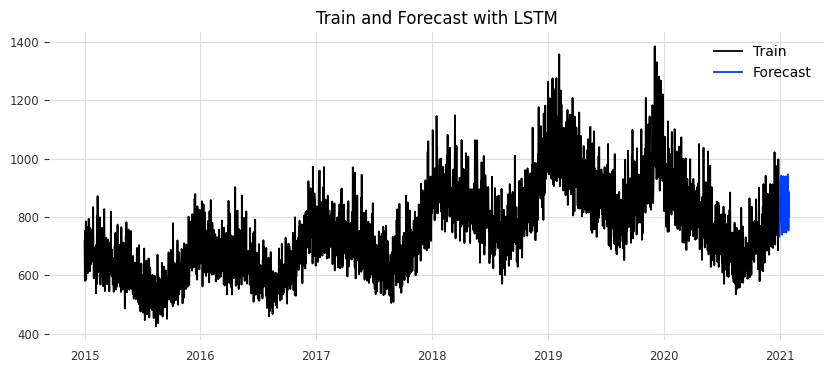

In [ ]:
plot_future(df.y,predictions,'LSTM')